# Candidate Problem Exploration: Review Prediction

**Framing (classification):** predict whether a delivered order will receive a **low review** (`review_score <= 2`) so the customer-experience team can reach out before the customer churns.

**Why this problem:** unlike delivery lateness (measured against Olist's own gameable estimate), the review score is the customer's own verdict — an ungameable target. And the data carries its likely *drivers*: the realised delivery experience, shipping-cost burden, order value, and the seller's / product's track record.

**Candidate features** (to build later, with leakage handled):
- mean past review score of the **product**, the **seller**, the **buyer** (as-of the order date, or train-only aggregates)
- **freight_value** and freight / price ratio
- **order value** (price)
- **delivery experience** — delivery days, and days vs. estimate bucketed (`5+ d early / 0-5 d early / 1-3 d late / 4+ d late`)

**This notebook is the descriptive pass only** — understand the reviews table (coverage, scores, titles, comments) before any modelling.

## 0. Setup & Data Loading

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

In [2]:
DATA_DIR = '../Olist_data'   # CSVs at repo root; this notebook runs from notebooks/

reviews   = pd.read_csv(f'{DATA_DIR}/olist_order_reviews_dataset.csv',
                        parse_dates=['review_creation_date', 'review_answer_timestamp'])
orders    = pd.read_csv(f'{DATA_DIR}/olist_orders_dataset.csv',
                        parse_dates=['order_purchase_timestamp', 'order_delivered_customer_date',
                                     'order_estimated_delivery_date'])
items     = pd.read_csv(f'{DATA_DIR}/olist_order_items_dataset.csv')
products  = pd.read_csv(f'{DATA_DIR}/olist_products_dataset.csv')
sellers   = pd.read_csv(f'{DATA_DIR}/olist_sellers_dataset.csv')
customers = pd.read_csv(f'{DATA_DIR}/olist_customers_dataset.csv')
cat_tr    = pd.read_csv(f'{DATA_DIR}/product_category_name_translation.csv')

for n, d in [('reviews', reviews), ('orders', orders), ('order_items', items),
             ('products', products), ('sellers', sellers), ('customers', customers)]:
    print(f'{n:12} {d.shape[0]:>7,} rows  x {d.shape[1]} cols')

reviews       99,224 rows  x 7 cols
orders        99,441 rows  x 8 cols
order_items  112,650 rows  x 7 cols
products      32,951 rows  x 9 cols
sellers        3,095 rows  x 4 cols
customers     99,441 rows  x 5 cols


## 1. Coverage — do >90% of orders really have a review?

Checking the join between `orders` and `reviews`: how many orders carry a review, how many reviews per order, and the known key quirks (a `review_id` shared by several orders, and vice versa).

In [3]:
n_orders = orders['order_id'].nunique()
print(f"orders total                  : {n_orders:,}")
print(f"review rows                   : {len(reviews):,}")
print(f"unique review_id              : {reviews['review_id'].nunique():,}")
print(f"unique order_id in reviews    : {reviews['order_id'].nunique():,}")
print(f"orders with >= 1 review       : {orders['order_id'].isin(reviews['order_id']).mean():.2%}")
print(f"fully duplicated review rows  : {reviews.duplicated().sum():,}")

rpo = reviews.groupby('order_id').size()
print(f"\nreviews per order:")
print(rpo.value_counts().sort_index().to_string())

rid = reviews.groupby('review_id')['order_id'].nunique()
oid = reviews.groupby('order_id')['review_id'].nunique()
print(f"\nreview_id linked to >1 order  : {(rid > 1).sum():,}")
print(f"order_id with >1 review_id    : {(oid > 1).sum():,}")

status = reviews.merge(orders[['order_id', 'order_status']], on='order_id', how='left')
print(f"\nreview rows by order_status:")
print(status['order_status'].value_counts(dropna=False).to_string())

orders total                  : 99,441
review rows                   : 99,224
unique review_id              : 98,410
unique order_id in reviews    : 98,673
orders with >= 1 review       : 99.23%
fully duplicated review rows  : 0

reviews per order:
1    98126
2      543
3        4



review_id linked to >1 order  : 789
order_id with >1 review_id    : 547

review rows by order_status:
order_status
delivered      96361
shipped         1043
canceled         609
unavailable      597
invoiced         313
processing       296
created            3
approved           2


## 2. Review score distribution

`review_score` is an integer 1–5, never null.

              count   pct
review_score             
1             11424 11.50
2              3151  3.20
3              8179  8.20
4             19142 19.30
5             57328 57.80

mean score       : 4.09
median score      : 5
score <= 2 (bad)  : 14.7%
score <= 3        : 22.9%
score == 5        : 57.8%
nulls in score    : 0


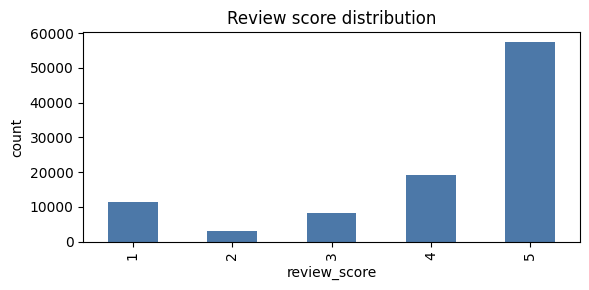

In [4]:
vc = reviews['review_score'].value_counts().sort_index()
dist = pd.DataFrame({'count': vc, 'pct': (vc / vc.sum() * 100).round(1)})
print(dist.to_string())
print(f"\nmean score       : {reviews['review_score'].mean():.2f}")
print(f"median score      : {reviews['review_score'].median():.0f}")
print(f"score <= 2 (bad)  : {(reviews['review_score'] <= 2).mean():.1%}")
print(f"score <= 3        : {(reviews['review_score'] <= 3).mean():.1%}")
print(f"score == 5        : {(reviews['review_score'] == 5).mean():.1%}")
print(f"nulls in score    : {reviews['review_score'].isna().sum()}")

ax = vc.plot(kind='bar', color='#4C78A8', figsize=(6, 3), title='Review score distribution')
ax.set_xlabel('review_score'); ax.set_ylabel('count')
plt.tight_layout(); plt.show()

## 3. Review titles (`review_comment_title`)

Short free-text headline. Optional — most reviewers leave it blank.

In [5]:
has_title = reviews['review_comment_title'].notna()
print(f"rows with a title : {has_title.mean():.1%}  ({has_title.sum():,})")

tl = reviews.loc[has_title, 'review_comment_title'].str.len()
print(f"title length (chars) — median {tl.median():.0f}, p90 {tl.quantile(.9):.0f}, max {tl.max():.0f}")

print("\ntop 15 titles (Portuguese):")
print(reviews['review_comment_title'].value_counts().head(15).to_string())

print("\ntitle-present rate by score:")
print(reviews.assign(has_title=has_title).groupby('review_score')['has_title'].mean().round(3).to_string())

rows with a title : 11.7%  (11,568)
title length (chars) — median 10, p90 21, max 26

top 15 titles (Portuguese):
review_comment_title
Recomendo          423
recomendo          345
Bom                293
super recomendo    270
Excelente          248
Muito bom          247
Ótimo              240
Super recomendo    217
Ótimo              207
Otimo              174
10                 158
Excelente          119
otimo              105
bom                 97
Muito bom           87

title-present rate by score:
review_score
1   0.16
2   0.15
3   0.10
4   0.09
5   0.12


## 4. Review comments (`review_comment_message`)

Longer free text. Present on ~40% of reviews, and — as the by-score breakdown shows — far more often on unhappy ones.

In [6]:
has_msg = reviews['review_comment_message'].notna()
print(f"rows with a message  : {has_msg.mean():.1%}  ({has_msg.sum():,})")
print(f"both title & message : {(has_title & has_msg).mean():.1%}")
print(f"neither              : {(~has_title & ~has_msg).mean():.1%}")

mc = reviews.loc[has_msg, 'review_comment_message'].str.len()
mw = reviews.loc[has_msg, 'review_comment_message'].str.split().str.len()
print(f"\nmessage length — chars: median {mc.median():.0f}, p90 {mc.quantile(.9):.0f}, max {mc.max():.0f}")
print(f"message length — words: median {mw.median():.0f}, p90 {mw.quantile(.9):.0f}")

print("\nmessage-present rate by score:")
print(reviews.assign(has_msg=has_msg).groupby('review_score')['has_msg'].mean().round(3).to_string())

rows with a message  : 41.3%  (40,977)
both title & message : 9.9%
neither              : 57.0%



message length — chars: median 53, p90 161, max 208
message length — words: median 9, p90 28

message-present rate by score:
review_score
1   0.77
2   0.68
3   0.43
4   0.31
5   0.36


In [7]:
# a few raw messages at each extreme (text is Portuguese)
for sc in (1, 5):
    print(f"--- sample messages, score {sc} ---")
    for m in reviews.loc[(reviews['review_score'] == sc) & has_msg, 'review_comment_message'].head(4):
        print("  ", m.replace("\n", " ")[:170])
    print()

--- sample messages, score 1 ---
   Péssimo
   Não gostei ! Comprei gato por lebre
   Sempre compro pela Internet e a entrega ocorre antes do prazo combinado, que acredito ser o prazo máximo. No stark o prazo máximo já se esgotou e ainda não recebi o produ
   Nada de chegar o meu pedido.

--- sample messages, score 5 ---
   Recebi bem antes do prazo estipulado.
   Parabéns lojas lannister adorei comprar pela Internet seguro e prático Parabéns a todos feliz Páscoa
   Vendedor confiável, produto ok e entrega antes do prazo.
   Loja nota 10



## 5. Score vs. the delivery experience

One score per order (mean where an order has several). Bucketed by how the actual delivery landed against Olist's estimate — the effect is large and monotonic, which is why delivery features head the candidate list.

In [8]:
o = orders[orders['order_status'] == 'delivered'].copy()
o['delivery_days']    = (o['order_delivered_customer_date'] - o['order_purchase_timestamp']).dt.days
o['days_vs_estimate'] = (o['order_delivered_customer_date'] - o['order_estimated_delivery_date']).dt.days

score_by_order = reviews.groupby('order_id')['review_score'].mean()
o = o.merge(score_by_order.rename('review_score'), on='order_id', how='inner')

o['delivery_bucket'] = pd.cut(o['days_vs_estimate'], [-10**6, -5, 0, 3, 10**6],
                              labels=['5+ d early', '0-5 d early', '1-3 d late', '4+ d late'])

tbl = o.groupby('delivery_bucket', observed=True)['review_score'].agg(
    mean_score='mean', n='size', pct_bad=lambda s: (s <= 2).mean())
print(tbl.round(3).to_string())

                 mean_score      n  pct_bad
delivery_bucket                            
5+ d early             4.31  81555     0.09
0-5 d early            4.12   7888     0.11
1-3 d late             3.29   1852     0.32
4+ d late              1.85   4529     0.75


## 6. Score over time and by category (brief)

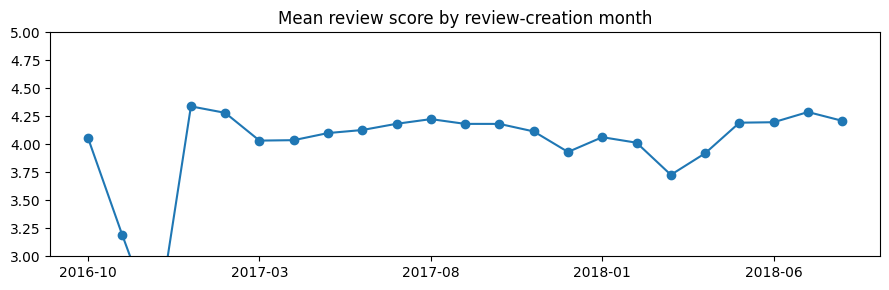

                               mean_score      n
product_category_name_english                   
bed_bath_table                       3.90  11137
furniture_decor                      3.90   8331
computers_accessories                3.93   7849
telephony                            3.95   4517
watches_gifts                        4.02   5950
garden_tools                         4.04   4329
housewares                           4.06   6943
auto                                 4.07   4213
sports_leisure                       4.11   8640
health_beauty                        4.14   9645
cool_stuff                           4.15   3772
toys                                 4.16   4091


In [9]:
monthly = reviews.groupby(reviews['review_creation_date'].dt.to_period('M'))['review_score'].mean()
monthly.index = monthly.index.astype(str)
ax = monthly.plot(figsize=(9, 3), marker='o', title='Mean review score by review-creation month')
ax.set_ylim(3, 5); ax.set_xlabel('')
plt.tight_layout(); plt.show()

it = items.merge(
    products.merge(cat_tr, on='product_category_name', how='left')[['product_id', 'product_category_name_english']],
    on='product_id', how='left')
it_rev = it.merge(reviews[['order_id', 'review_score']], on='order_id', how='inner')
top = it_rev['product_category_name_english'].value_counts().head(12).index
cat_score = (it_rev[it_rev['product_category_name_english'].isin(top)]
             .groupby('product_category_name_english')['review_score']
             .agg(mean_score='mean', n='size').sort_values('mean_score'))
print(cat_score.round(2).to_string())

## 7. Toward the classification model

**Target.** `bad_review = (review_score <= 2)` — about 15% of orders, so a moderate class imbalance (handle with class weights / threshold tuning, as in the delivery notebook). A `<= 3` variant (~23%) is the softer alternative.

**One row per order.** Take the mean (or first) score per `order_id`; drop the ~789 `review_id`s that span multiple orders.

**Feature build + leakage notes:**
- *Delivery experience* (`delivery_days`, `days_vs_estimate`, bucket) — the review is written after delivery, so these are known at prediction time. Safe.
- *Order attributes* (`freight_value`, freight / price, order `price`, `n_items`, `category`, seller/customer state, distance) — safe.
- *Past mean review score of seller / product / buyer* — **leakage risk**: must use only reviews from orders **purchased earlier** than the current one (as-of aggregation), or a train-only global mean. Note coverage: buyers are ~97% one-time so buyer history is mostly empty; product history is sparse; **seller history is the usable one**.
- *Title / comment text* — written at review time, so it can't feed a pre-review risk model; keep it for a separate "why" analysis.

**Next steps:** build the order-level table, define the target, one stratified split, baseline classifiers (LogReg / RF / HistGB with balanced weights), then threshold tuning.